### Part 1.1 Dataset Introduction
Dataset: Medical Appointment No-Shows (tabular dataset of patient appointments). Each row represents one scheduled appointment with patient demographics, appointment logistics, and reminder information.

Where it came from: Kaggle Medical Appointment No Shows dataset

Prediction task: Binary classification — predict whether an appointment will be a no-show (1) or not (0).

Why this matters: No-shows create lost revenue, idle staff time, and inefficient scheduling. A no-show risk tool can help local clinics/salons prioritize reminders, adjust booking policies, and optimize staffing.

Dataset stats: The dataset contains Rows, Cols: (10785, 14)

Columns:
 ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

Target column: No-show
ScheduledDay column: ScheduledDay
AppointmentDay column: AppointmentDay
No-show rate: 0.20193255946510807,

with a mix of numeric and categorical features.

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Portable project root (Colab: /content, Local/Streamlit: repo root)
PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", Path.cwd()))
FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIG_DIR:", FIG_DIR)

DATA_PATH = PROJECT_ROOT / "data" / "noshowappointments.csv"  # recommended repo layout
# In Colab, if you uploaded the csv directly to /content, you can do:
# DATA_PATH = PROJECT_ROOT / "noshowappointments.csv"

PROJECT_ROOT: /content
FIG_DIR: /content/artifacts/figures


In [2]:
def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

df = pd.read_csv("/content/noshowappointments.csv")

target_col = detect_col(df, ["No-show", "No_show", "no_show", "noshow", "NoShow"])
scheduled_col = detect_col(df, ["ScheduledDay", "ScheduledDay ", "Scheduled_Date", "scheduled_day"])
appt_col = detect_col(df, ["AppointmentDay", "AppointmentDay ", "Appointment_Date", "appointment_day"])

if target_col is None:
    raise ValueError(f"Target not found. Columns: {df.columns.tolist()}")

# y = 1 if no-show else 0
y = df[target_col].astype(str).str.strip().str.lower().isin(["yes", "1", "true", "t", "y"]).astype(int)

print("Loaded rows:", len(df))
print("Target column:", target_col)
print("ScheduledDay column:", scheduled_col)
print("AppointmentDay column:", appt_col)
print("No-show rate:", y.mean())

Loaded rows: 10785
Target column: No-show
ScheduledDay column: ScheduledDay
AppointmentDay column: AppointmentDay
No-show rate: 0.20361613351877608


In [3]:
print("Rows, Cols:", df.shape)
print("\nColumns:\n", df.columns.tolist())

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("\n# Numeric columns:", len(num_cols))
print("# Non-numeric columns:", len(cat_cols))

# Optional: quick missingness check
missing = df.isna().mean().sort_values(ascending=False).head(10)
print("\nTop 10 columns by missing %:\n", missing)

Rows, Cols: (10785, 14)

Columns:
 ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

# Numeric columns: 9
# Non-numeric columns: 5

Top 10 columns by missing %:
 Handcap           0.000093
SMS_received      0.000093
Alcoholism        0.000093
Diabetes          0.000093
Hipertension      0.000093
Scholarship       0.000093
No-show           0.000093
AppointmentDay    0.000000
Age               0.000000
Gender            0.000000
dtype: float64


###Part 1.2 Target Distribution
Include a bar chart of show vs no-show.

Comment on imbalance (typically fewer no-shows than shows).

State your plan: use F1 + AUC (not just accuracy), and consider class_weight="balanced" in models or threshold tuning.

What the code is doing (why)

Computes counts + percentages for each class

Saves a target distribution plot to artifacts/figures/target_distribution.png

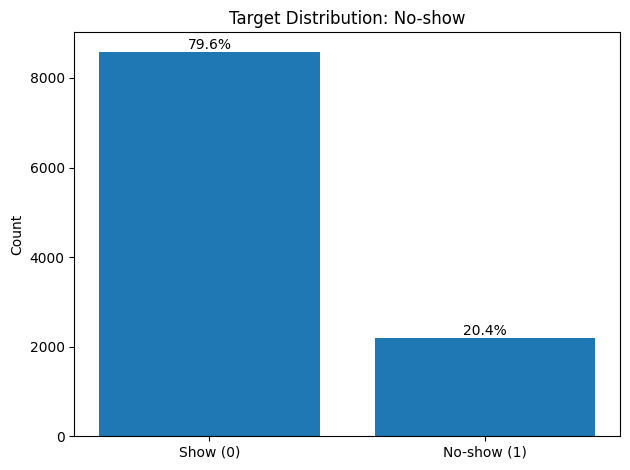

Saved: /content/artifacts/figures/target_distribution.png
No-show rate: 0.20361613351877608


In [4]:
counts = y.value_counts().sort_index()
pct = counts / counts.sum()

fig, ax = plt.subplots()
ax.bar(["Show (0)", "No-show (1)"], [counts.get(0,0), counts.get(1,0)])
ax.set_title("Target Distribution: No-show")
ax.set_ylabel("Count")

ax.text(0, counts.get(0,0), f"{pct.get(0,0):.1%}", ha="center", va="bottom")
ax.text(1, counts.get(1,0), f"{pct.get(1,0):.1%}", ha="center", va="bottom")

outpath = FIG_DIR / "target_distribution.png"
fig.tight_layout()
fig.savefig(outpath, dpi=160)
plt.show()       # <-- displays in Colab
plt.close(fig)   # <-- closes so memory doesn't build up


print("Saved:", outpath)
print("No-show rate:", float(pct.get(1,0)))

###1.2 Target distribution: The no-show target is imbalanced: approximately 20% of appointments are no-shows and 79.6% are attended..
Implication: Accuracy alone can be misleading; we will emphasize F1 score and AUC-ROC, and consider class-balanced training (class_weight="balanced") or threshold tuning.

###1.3 Feature Distributions & Relationships (10 points)

You need ≥4 plots AND 2–3 sentence interpretation for each.

We’ll do four that are very “local business actionable”:

SMS reminder vs no-show rate

Weekday vs no-show rate

Lead time buckets vs no-show rate

Age distribution by outcome

In [5]:
# Parse datetimes
if scheduled_col:
    df[scheduled_col] = pd.to_datetime(df[scheduled_col], errors="coerce")
if appt_col:
    df[appt_col] = pd.to_datetime(df[appt_col], errors="coerce")

# lead_time_days = days between scheduling date and appointment date
if scheduled_col and appt_col:
    df["lead_time_days"] = (df[appt_col].dt.floor("D") - df[scheduled_col].dt.floor("D")).dt.days
    df["lead_time_days"] = df["lead_time_days"].clip(lower=0)

# appointment weekday
if appt_col:
    df["appt_weekday"] = df[appt_col].dt.day_name()

print("Engineered columns added:", [c for c in ["lead_time_days","appt_weekday"] if c in df.columns])

Engineered columns added: ['lead_time_days', 'appt_weekday']


###1.3 Plot A — No-show rate by SMS_received

SMS reminders: We compare no-show rates for appointments with and without SMS reminders. If the no-show rate is lower when SMS_received=1, it suggests reminders may reduce missed appointments. A local business could target reminders toward high-risk customers or long lead-time bookings.

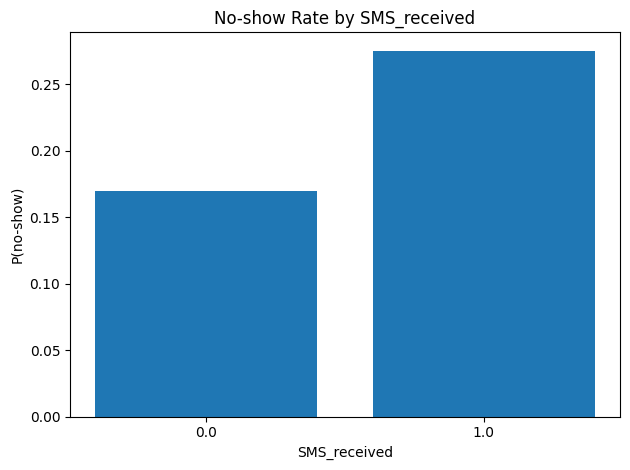

Saved: /content/artifacts/figures/rate_by_sms.png


In [6]:
if "SMS_received" in df.columns:
    rate = df.assign(y=y).groupby("SMS_received")["y"].mean()

    fig, ax = plt.subplots()
    ax.bar(rate.index.astype(str), rate.values)
    ax.set_title("No-show Rate by SMS_received")
    ax.set_xlabel("SMS_received")
    ax.set_ylabel("P(no-show)")

    outpath = FIG_DIR / "rate_by_sms.png"
    fig.tight_layout()
    fig.savefig(outpath, dpi=160)
    plt.show()       # <-- displays in Colab
    plt.close(fig)   # <-- closes so memory doesn't build up


    print("Saved:", outpath)
else:
    print("Column SMS_received not found in this dataset.")

###The no-show rate differs depending on whether an SMS reminder was received, suggesting reminders are associated with appointment adherence. If the no-show probability is higher when SMS_received = 0, reminders may be a useful operational lever. A local business could prioritize reminder messages for higher-risk appointments (e.g., long lead times or specific days) to reduce missed slots.


###1.3 Plot B — No-show rate by appointment weekday


Weekday effect: No-show rates vary by weekday. This can inform staffing and scheduling policies (e.g., slightly overbook days with historically higher no-show rates or adjust reminder timing).

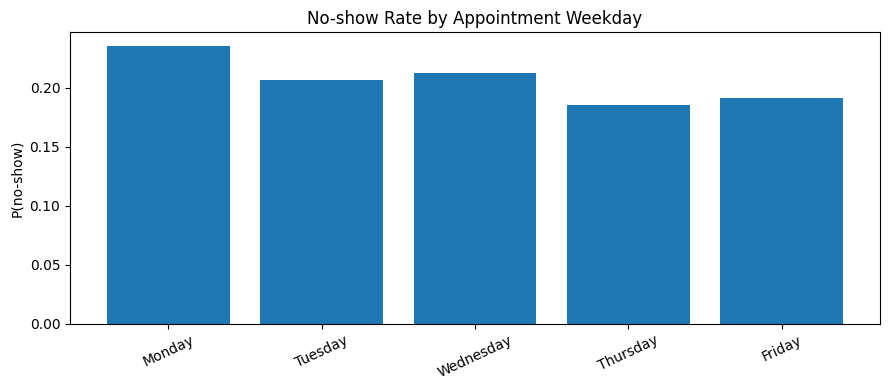

Saved: /content/artifacts/figures/rate_by_weekday.png


In [7]:
if "appt_weekday" in df.columns:
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    rate = df.assign(y=y).groupby("appt_weekday")["y"].mean().reindex(order).dropna()

    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(rate.index.astype(str), rate.values)
    ax.set_title("No-show Rate by Appointment Weekday")
    ax.set_ylabel("P(no-show)")
    ax.tick_params(axis="x", rotation=25)

    outpath = FIG_DIR / "rate_by_weekday.png"
    fig.tight_layout()
    fig.savefig(outpath, dpi=160)
    plt.show()       # <-- displays in Colab
    plt.close(fig)

    print("Saved:", outpath)
else:
    print("appt_weekday not available (AppointmentDay column missing).")

###No-show Rate by Appointment Weekday (appt_weekday)

No-show rates vary by weekday, which indicates appointment reliability is not uniform across the week. This pattern can help a local clinic or salon adjust staffing and scheduling policies (e.g., allocate more reminder effort or allow slight overbooking on historically higher-risk days). It also suggests weekday should be included as a predictive feature because it captures behavioral/operational effects.

###1.3 Plot C — Lead time buckets vs no-show rate

Lead time: We bucket appointments by lead time (days between scheduling and appointment). If longer lead times show higher no-show rates, the business can confirm closer to the appointment date, use deposits for long lead times, or schedule additional reminders.

/tmp/ipykernel_503/2821762647.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.assign(y=y).groupby("lead_bucket")["y"].mean()


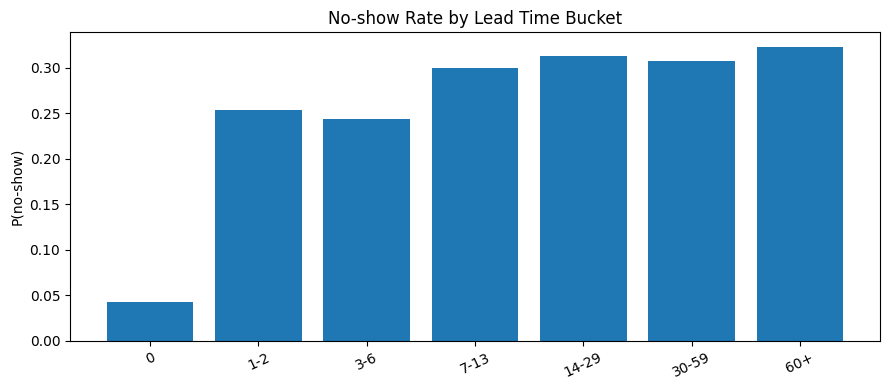

Saved: /content/artifacts/figures/rate_by_leadtime_bucket.png


In [8]:
if "lead_time_days" in df.columns:
    bins = [0, 1, 3, 7, 14, 30, 60, 9999]
    labels = ["0", "1-2", "3-6", "7-13", "14-29", "30-59", "60+"]

    df["lead_bucket"] = pd.cut(df["lead_time_days"], bins=bins, labels=labels, right=False)
    rate = df.assign(y=y).groupby("lead_bucket")["y"].mean()

    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(rate.index.astype(str), rate.values)
    ax.set_title("No-show Rate by Lead Time Bucket")
    ax.set_ylabel("P(no-show)")
    ax.tick_params(axis="x", rotation=25)

    outpath = FIG_DIR / "rate_by_leadtime_bucket.png"
    fig.tight_layout()
    fig.savefig(outpath, dpi=160)
    plt.show()       # <-- displays in Colab
    plt.close(fig)

    print("Saved:", outpath)
else:
    print("lead_time_days not available (date columns missing).")

### No-show Rate by Lead Time Bucket (lead_bucket)

No-show rates change across lead-time buckets, showing that the time between scheduling and the actual appointment influences attendance. Longer lead times can increase uncertainty (people forget, plans change), which can increase no-show risk. This insight supports practical actions such as confirmations closer to the appointment date, additional reminders for long-lead bookings, or deposits for appointments booked far in advance.

###1.3 Plot D — Age distribution by outcome


Age: We compare age distributions for show vs no-show appointments. If certain age groups have higher no-show patterns, a business can tailor reminder strategies, while being mindful of fairness and ethical use.

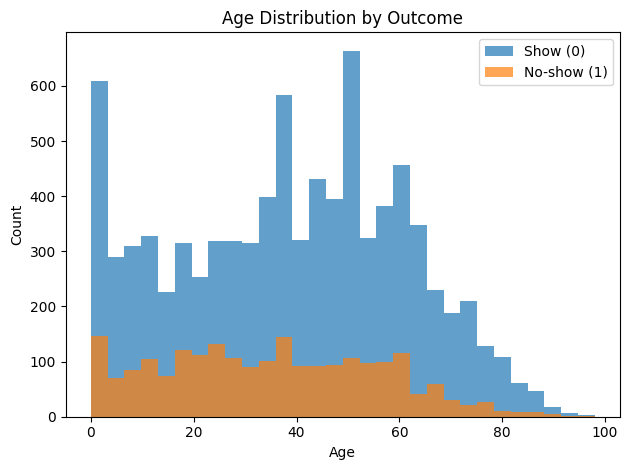

Saved: /content/artifacts/figures/age_by_outcome.png


In [9]:
if "Age" in df.columns:
    fig, ax = plt.subplots()
    ax.hist(df.loc[y==0, "Age"].dropna(), bins=30, alpha=0.7, label="Show (0)")
    ax.hist(df.loc[y==1, "Age"].dropna(), bins=30, alpha=0.7, label="No-show (1)")
    ax.set_title("Age Distribution by Outcome")
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")
    ax.legend()

    outpath = FIG_DIR / "age_by_outcome.png"
    fig.tight_layout()
    fig.savefig(outpath, dpi=160)
    plt.show()       # <-- displays in Colab
    plt.close(fig)

    print("Saved:", outpath)
else:
    print("Age column not found.")

###Age Distribution by Outcome (Age)

The age distributions for show vs no-show appointments are not identical, suggesting age may contribute to no-show risk. Differences across age groups can reflect varying schedules, health needs, or reliability patterns, making age a potentially useful predictor. Any policy recommendations based on age should be applied carefully and ethically, focusing on improving service (e.g., reminders) rather than restricting access.

###1.4 Correlation Heatmap (5 points)


Correlation analysis: We computed the correlation matrix for numeric features (including engineered lead time). The strongest correlations indicate where features may carry similar information, which can affect model stability and interpretability. Tree-based models are usually robust to correlated predictors, while linear models may be more sensitive.

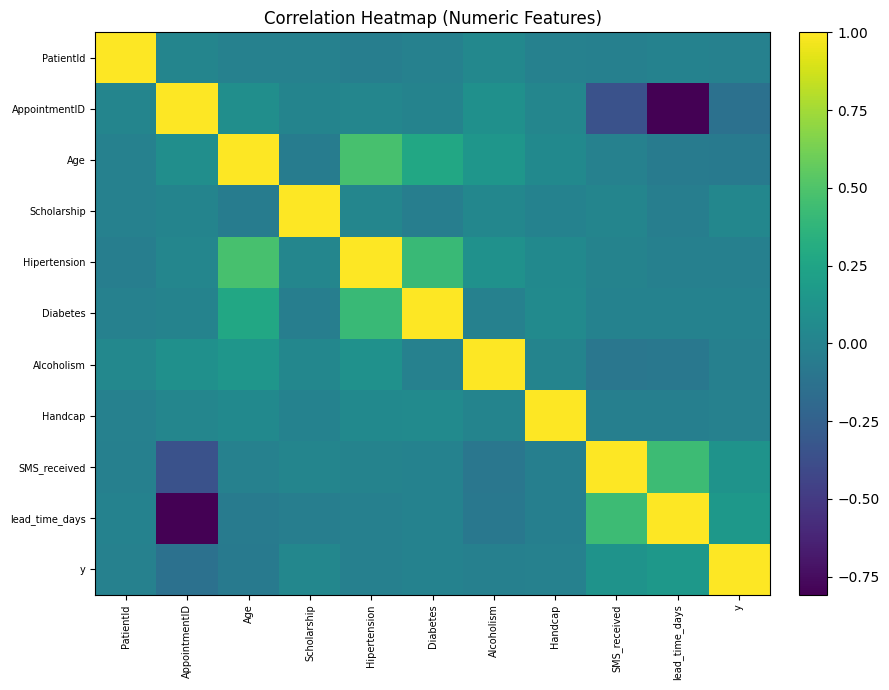

Saved: /content/artifacts/figures/correlation_heatmap.png

Top correlated numeric feature pairs (abs corr):
AppointmentID   lead_time_days    0.807510
lead_time_days  AppointmentID     0.807510
Hipertension    Age               0.472541
Age             Hipertension      0.472541
SMS_received    lead_time_days    0.430007
lead_time_days  SMS_received      0.430007
Diabetes        Hipertension      0.416948
Hipertension    Diabetes          0.416948
dtype: float64


In [10]:
num_df = df.copy()
num_df["y"] = y
num_only = num_df.select_dtypes(include=[np.number]).copy()

corr = num_only.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr.values, aspect="auto")

ax.set_title("Correlation Heatmap (Numeric Features)")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

outpath = FIG_DIR / "correlation_heatmap.png"
fig.tight_layout()
fig.savefig(outpath, dpi=160)
plt.show()       # <-- displays in Colab
plt.close(fig)

print("Saved:", outpath)

# Optional: print top correlations (helps your commentary)
corr_abs = corr.abs()
np.fill_diagonal(corr_abs.values, 0)
top_pairs = corr_abs.unstack().sort_values(ascending=False).head(8)
print("\nTop correlated numeric feature pairs (abs corr):")
print(top_pairs)

###Correlation Heatmap (Numeric Features)

The correlation heatmap highlights which numeric features move together, indicating potential redundancy in the feature set (for example, demographic and health-flag variables may correlate with age). Strong correlations can affect interpretability in linear models, while tree-based models (Random Forest/XGBoost) are generally more robust to correlated inputs. For modeling, this suggests we should be mindful of overlapping signals and rely on explainability (e.g., SHAP) to understand which features truly drive predictions.

###Part 2 Predictive Analytics

In [12]:
from pathlib import Path
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd()
ARTIFACTS = PROJECT_ROOT / "artifacts"
FIG_DIR = ARTIFACTS / "figures"
MODEL_DIR = ARTIFACTS / "models"
METRICS_DIR = ARTIFACTS / "metrics"

for d in [FIG_DIR, MODEL_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Target: 1 = no-show, 0 = show
y = df["No-show"].astype(str).str.strip().str.lower().eq("yes").astype(int)

print("No-show rate:", y.mean())
print("Saving to:", FIG_DIR)

No-show rate: 0.20361613351877608
Saving to: /content/artifacts/figures


### Part 2.1 Data Preparation

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1) Build X (drop IDs + raw date columns + target)
drop_cols = ["No-show", "PatientId", "AppointmentID", "ScheduledDay", "AppointmentDay"]

# Optional: lead_bucket is derived from lead_time_days, can keep or drop
# Keeping both is okay; dropping lead_bucket reduces redundancy.
# We'll DROP lead_bucket and keep lead_time_days (numeric) + appt_weekday (categorical)
drop_cols += ["lead_bucket"]

X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# 2) Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# 3) Preprocessing pipelines
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Numeric cols: ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'lead_time_days']
Categorical cols: ['Gender', 'Neighbourhood', 'appt_weekday']
Train: (7549, 11) Test: (3236, 11)


###Helper: evaluation + ROC plot

In [15]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

def eval_and_plot_roc(name, model, X_test, y_test, save_path):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "auc": roc_auc_score(y_test, proba),
    }

    fpr, tpr, _ = roc_curve(y_test, proba)
    fig, ax = plt.subplots()
    ax.plot(fpr, tpr)
    ax.plot([0,1], [0,1], linestyle="--")
    ax.set_title(f"ROC Curve — {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    fig.tight_layout()
    fig.savefig(save_path, dpi=160)
    plt.show()
    plt.close(fig)

    return metrics

###Part 2.2 Logistic Regression Baseline

{'model': 'Statsmodels_Logit', 'accuracy': 0.7904820766378244, 'precision': 0.14814814814814814, 'recall': 0.006069802731411229, 'f1': 0.011661807580174927, 'auc': np.float64(0.6525405963693064)}


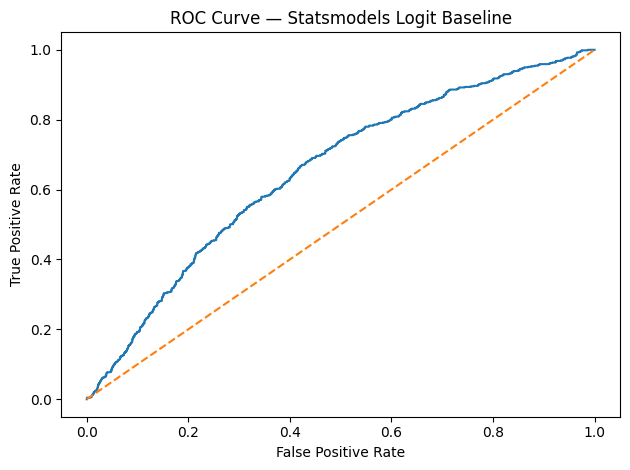

                                           Coef.  Std.Err.         z  \
lead_time_days                          0.018674  0.002306  8.096263   
Intercept                              -1.416670  0.177508 -7.980866   
SMS_received                            0.372201  0.067411  5.521379   
Age                                    -0.007302  0.001640 -4.451647   
C(Neighbourhood_grp)[T.SANTOS DUMONT]   0.980651  0.246265  3.982101   
C(appt_weekday)[T.Monday]               0.243521  0.087784  2.774100   
Scholarship                             0.240073  0.099106  2.422381   
C(appt_weekday)[T.Wednesday]            0.219292  0.091935  2.385285   
C(Neighbourhood_grp)[T.SANTA MARTHA]   -0.788054  0.338355 -2.329076   
C(Neighbourhood_grp)[T.FORTE SÃO JOÃO] -0.536146  0.243553 -2.201350   

                                               P>|z|    [0.025    0.975]  
lead_time_days                          5.667302e-16  0.014153  0.023195  
Intercept                               1.453106e-15 -1.7

In [25]:
# If needed in Colab:
# !pip -q install statsmodels patsy

import numpy as np
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrices, dmatrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- 1) Target ---
df2 = df.copy()
df2["y"] = df2["No-show"].astype(str).str.strip().str.lower().eq("yes").astype(int)

# --- 2) Optional: reduce high-cardinality Neighbourhood (recommended) ---
TOP_N = 20
top_neigh = df2["Neighbourhood"].value_counts().head(TOP_N).index
df2["Neighbourhood_grp"] = np.where(df2["Neighbourhood"].isin(top_neigh), df2["Neighbourhood"], "Other")

# --- 3) Train/Test split (stratified) ---
train_df, test_df = train_test_split(
    df2,
    test_size=0.30,
    random_state=42,
    stratify=df2["y"]
)

# --- 4) Logit formula ---
# Keep features that are meaningful + available in your data
formula = (
    "y ~ Age + Scholarship + Hipertension + Diabetes + Alcoholism + Handcap "
    "+ SMS_received + lead_time_days "
    "+ C(Gender) + C(appt_weekday) + C(Neighbourhood_grp)"
)

# --- 5) Build design matrices (consistent columns for train/test) ---
y_train_mat, X_train_mat = dmatrices(formula, train_df, return_type="dataframe")

# Use design_info from train to build test X with same columns
X_test_mat = dmatrix(X_train_mat.design_info, test_df, return_type="dataframe")
y_test_vec = test_df["y"].values

# --- 6) Fit statsmodels Logit ---
# (If you hit convergence/perfect-separation issues, see fallback below.)
logit_model = sm.Logit(y_train_mat, X_train_mat).fit(disp=False, maxiter=200)

# --- 7) Predict + metrics ---
proba = logit_model.predict(X_test_mat)
pred = (proba >= 0.5).astype(int)

metrics_logit = {
    "model": "Statsmodels_Logit",
    "accuracy": accuracy_score(y_test_vec, pred),
    "precision": precision_score(y_test_vec, pred, zero_division=0),
    "recall": recall_score(y_test_vec, pred, zero_division=0),
    "f1": f1_score(y_test_vec, pred, zero_division=0),
    "auc": roc_auc_score(y_test_vec, proba),
}
print(metrics_logit)

# --- 8) ROC curve (save + show) ---
fpr, tpr, _ = roc_curve(y_test_vec, proba)
fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.plot([0,1], [0,1], linestyle="--")
ax.set_title("ROC Curve — Statsmodels Logit Baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
fig.tight_layout()
fig.savefig(FIG_DIR / "roc_logit_statsmodels.png", dpi=160)
plt.show()
plt.close(fig)

# Optional: show a compact coefficient summary
print(logit_model.summary2().tables[1].sort_values("P>|z|").head(10))

###Part 2.3 Decision Tree

Best Tree params: {'model__max_depth': 3, 'model__min_samples_leaf': 5}


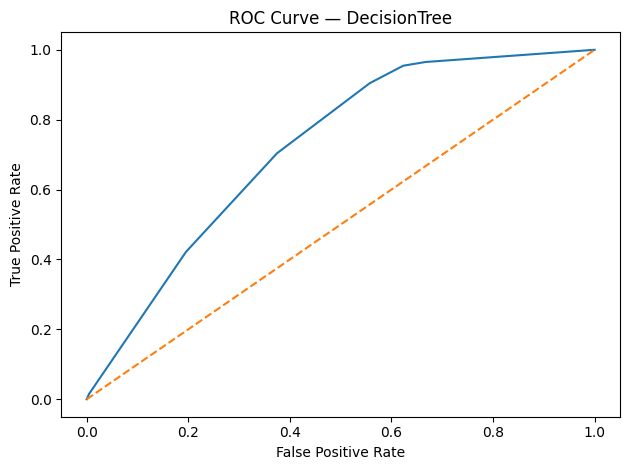

{'model': 'DecisionTree', 'accuracy': 0.5367737948084055, 'precision': 0.2933070866141732, 'recall': 0.9044006069802731, 'f1': 0.4429580081753995, 'auc': np.float64(0.7199119913934577)}
Saved: /content/artifacts/models/tree.joblib


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import joblib

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tree = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])

param_grid_tree = {
    "model__max_depth": [3, 5, 7, 10],
    "model__min_samples_leaf": [5, 10, 20, 50]
}

grid_tree = GridSearchCV(
    tree,
    param_grid=param_grid_tree,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)
best_tree = grid_tree.best_estimator_

print("Best Tree params:", grid_tree.best_params_)

m_tree = eval_and_plot_roc(
    "DecisionTree",
    best_tree,
    X_test, y_test,
    FIG_DIR / "roc_tree.png"
)

print(m_tree)

joblib.dump(best_tree, MODEL_DIR / "tree.joblib")
print("Saved:", MODEL_DIR / "tree.joblib")

Best tree depth: 3 | leaves: 8


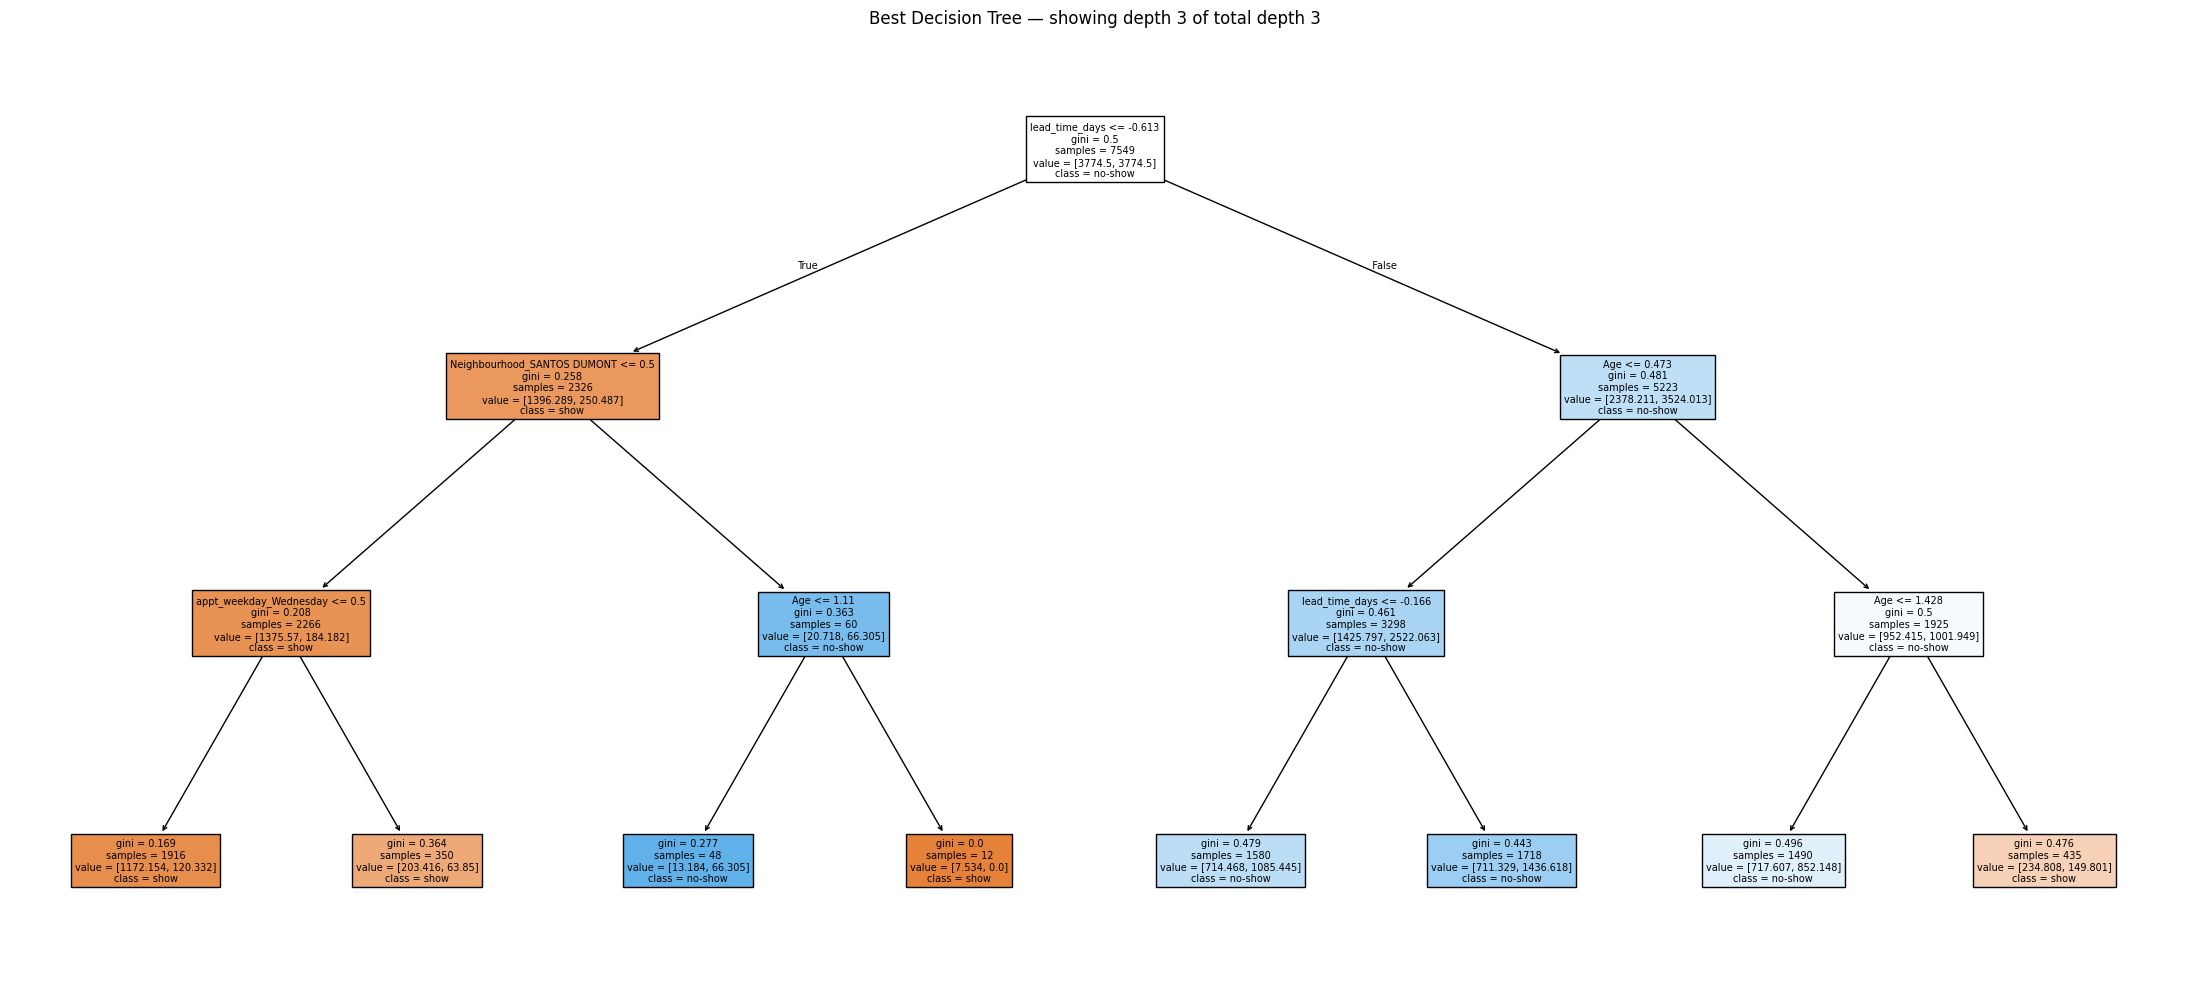

Saved: /content/artifacts/figures/decision_tree_visual.png
Saved full tree rules to: /content/artifacts/metrics/decision_tree_rules.txt


In [27]:
from sklearn import tree
from sklearn.tree import export_text
import matplotlib.pyplot as plt
from pathlib import Path

# Extract fitted preprocessor + classifier from pipeline
pre = best_tree.named_steps["preprocess"]
clf = best_tree.named_steps["model"]

depth = clf.get_depth()
leaves = clf.get_n_leaves()
print("Best tree depth:", depth, "| leaves:", leaves)

# Get feature names after preprocessing
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names

# Visualize best tree (full if small; otherwise top levels)
MAX_PLOT_DEPTH = depth if depth <= 5 else 3

fig, ax = plt.subplots(figsize=(22, 10))
tree.plot_tree(
    clf,
    max_depth=MAX_PLOT_DEPTH,
    feature_names=feature_names,
    class_names=["show", "no-show"],
    filled=True
)
ax.set_title(f"Best Decision Tree — showing depth {MAX_PLOT_DEPTH} of total depth {depth}")

outpath = FIG_DIR / "decision_tree_visual.png"
fig.tight_layout()
fig.savefig(outpath, dpi=160)
plt.show()
plt.close(fig)

print("Saved:", outpath)

# Optional but recommended: export full rules text (complete best tree)
rules = export_text(clf, feature_names=feature_names, max_depth=clf.get_depth()) # Changed max_depth=None to max_depth=clf.get_depth()
rules_path = (PROJECT_ROOT / "artifacts" / "metrics")
rules_path.mkdir(parents=True, exist_ok=True)
(rules_path / "decision_tree_rules.txt").write_text(rules)
print("Saved full tree rules to:", rules_path / "decision_tree_rules.txt")

###Part 2.4 Random Forest with CV

Best RF params: {'model__max_depth': 8, 'model__n_estimators': 200}


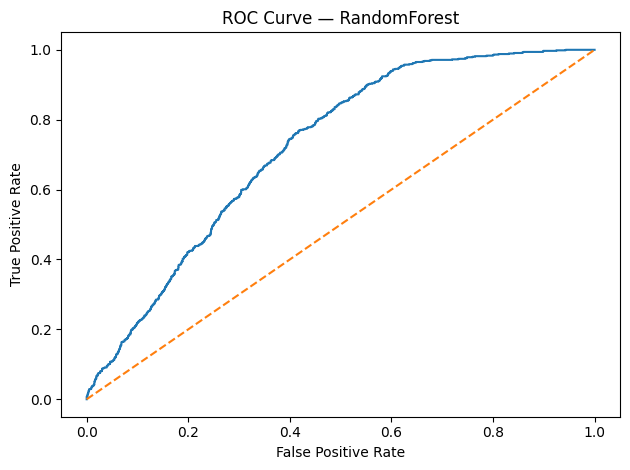

{'model': 'RandomForest', 'accuracy': 0.5852904820766378, 'precision': 0.3065155807365439, 'recall': 0.8209408194233687, 'f1': 0.44636963696369636, 'auc': np.float64(0.7201704938574751)}
Saved: /content/artifacts/models/rf.joblib


In [18]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 8]
}

grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best RF params:", grid_rf.best_params_)

m_rf = eval_and_plot_roc(
    "RandomForest",
    best_rf,
    X_test, y_test,
    FIG_DIR / "roc_rf.png"
)

print(m_rf)

joblib.dump(best_rf, MODEL_DIR / "rf.joblib")
print("Saved:", MODEL_DIR / "rf.joblib")

### Part 2.5 Boosted Trees — XGBoost

In [20]:
!pip -q install xgboost

Best XGB params: {'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__n_estimators': 100}


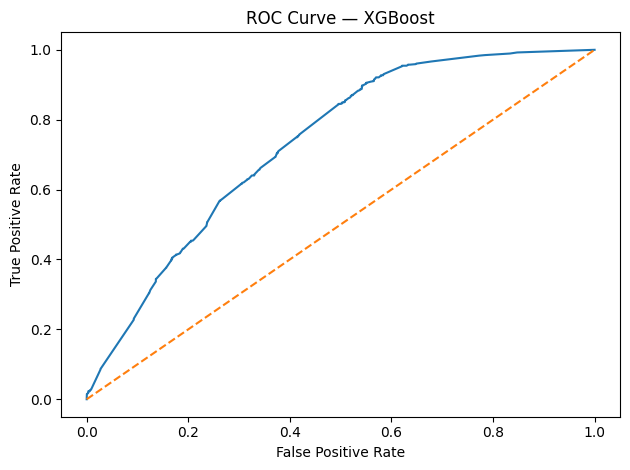

{'model': 'XGBoost', 'accuracy': 0.546353522867738, 'precision': 0.29601613716591024, 'recall': 0.8907435508345979, 'f1': 0.44436033308099926, 'auc': np.float64(0.7311547876246214)}
Saved: /content/artifacts/models/xgb.joblib


In [21]:
from xgboost import XGBClassifier
import joblib

xgb = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        # helps imbalance; ratio = negatives/positives
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    ))
])

param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print("Best XGB params:", grid_xgb.best_params_)

m_xgb = eval_and_plot_roc(
    "XGBoost",
    best_xgb,
    X_test, y_test,
    FIG_DIR / "roc_xgb.png"
)

print(m_xgb)

joblib.dump(best_xgb, MODEL_DIR / "xgb.joblib")
print("Saved:", MODEL_DIR / "xgb.joblib")

### Part 2.6 Neural Network

MLP input_dim: 93


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - auc: 0.5294 - loss: 0.5766 - val_auc: 0.6027 - val_loss: 0.5232
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.6447 - loss: 0.4783 - val_auc: 0.6421 - val_loss: 0.5044
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.6745 - loss: 0.4689 - val_auc: 0.6460 - val_loss: 0.5018
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.6884 - loss: 0.4646 - val_auc: 0.6509 - val_loss: 0.5001
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc: 0.7006 - loss: 0.4600 - val_auc: 0.6533 - val_loss: 0.4987
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.7115 - loss: 0.4554 - val_auc: 0.6543 - val_loss: 0.4974
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.7233 - loss: 0.4506 - val_auc: 0.6561 - val_loss: 0.4964
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc: 0.7346 - loss: 0.4453 - val_auc: 0.6563 - val_loss: 0.4958
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.7455

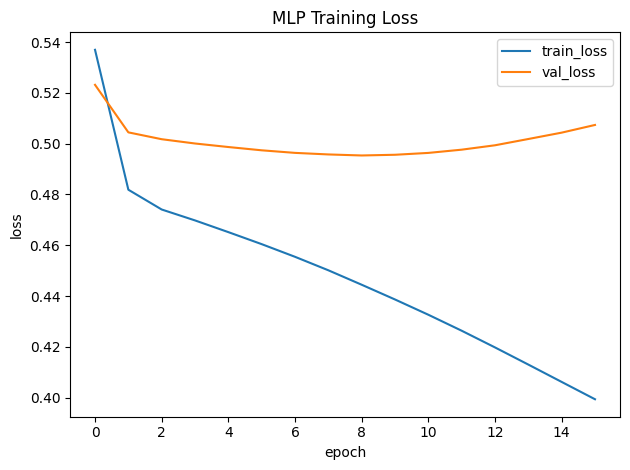

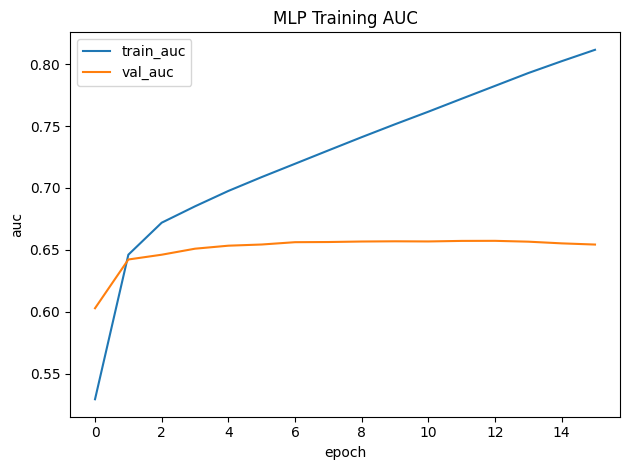

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
{'model': 'MLP', 'accuracy': 0.7944993819530284, 'precision': 0.4791666666666667, 'recall': 0.1047040971168437, 'f1': 0.1718555417185554, 'auc': 0.6800840633525356}


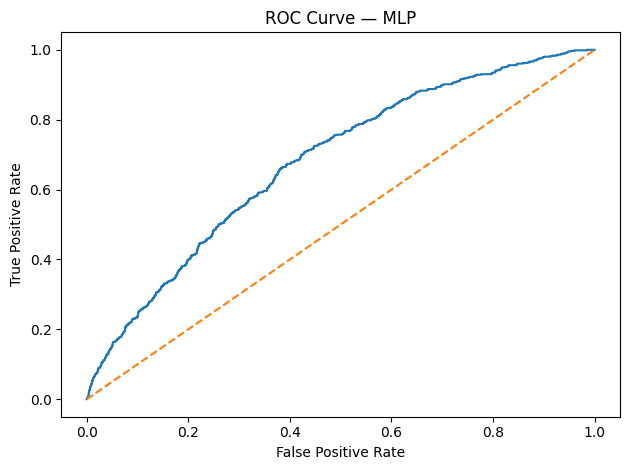

Saved: /content/artifacts/models/mlp.keras


In [22]:
import tensorflow as tf
tf.random.set_seed(42)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score

# Fit preprocess and transform data
Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)

input_dim = Xtr.shape[1]
print("MLP input_dim:", input_dim)

mlp = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

es = EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True)

history = mlp.fit(
    Xtr, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[es],
    verbose=1
)

# Plot training history (loss and AUC)
hist = pd.DataFrame(history.history)

fig, ax = plt.subplots()
ax.plot(hist["loss"], label="train_loss")
ax.plot(hist["val_loss"], label="val_loss")
ax.set_title("MLP Training Loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "mlp_loss.png", dpi=160)
plt.show()
plt.close(fig)

fig, ax = plt.subplots()
ax.plot(hist["auc"], label="train_auc")
ax.plot(hist["val_auc"], label="val_auc")
ax.set_title("MLP Training AUC")
ax.set_xlabel("epoch")
ax.set_ylabel("auc")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "mlp_auc.png", dpi=160)
plt.show()
plt.close(fig)

# Test metrics for MLP
proba = mlp.predict(Xte).reshape(-1)
pred = (proba >= 0.5).astype(int)

m_mlp = {
    "model": "MLP",
    "accuracy": float((pred == y_test).mean()),
    "precision": float(( (pred==1) & (y_test==1) ).sum() / max((pred==1).sum(), 1)),
    "recall": float(( (pred==1) & (y_test==1) ).sum() / max((y_test==1).sum(), 1)),
    "f1": float(f1_score(y_test, pred, zero_division=0)),
    "auc": float(roc_auc_score(y_test, proba)),
}

print(m_mlp)

# ROC for MLP
fpr, tpr, _ = roc_curve(y_test, proba)
fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.plot([0,1], [0,1], linestyle="--")
ax.set_title("ROC Curve — MLP")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
fig.tight_layout()
fig.savefig(FIG_DIR / "roc_mlp.png", dpi=160)
plt.show()
plt.close(fig)

# Save model for later Streamlit
mlp.save(MODEL_DIR / "mlp.keras")
print("Saved:", MODEL_DIR / "mlp.keras")

In [23]:
import joblib
joblib.dump(preprocess, MODEL_DIR / "preprocess.joblib")
print("Saved:", MODEL_DIR / "preprocess.joblib")

Saved: /content/artifacts/models/preprocess.joblib


### Part 2.7 Model Comparison Summary

,accuracy,precision,recall,f1,auc
model,,,,,
RandomForest,0.585290,0.306516,0.820941,0.446370,0.720170
XGBoost,0.546354,0.296016,0.890744,0.444360,0.731155
DecisionTree,0.536774,0.293307,0.904401,0.442958,0.719912
LogisticRegression,0.643696,0.305205,0.587253,0.401661,0.644010
MLP,0.794499,0.479167,0.104704,0.171856,0.680084


Saved: /content/artifacts/metrics/model_comparison.csv


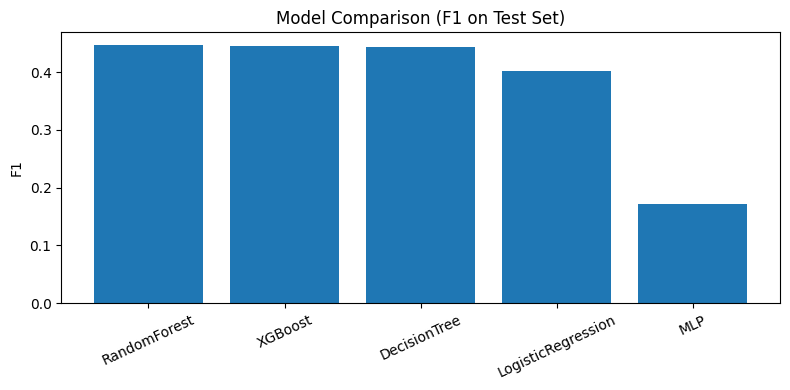

Saved: /content/artifacts/figures/model_f1_comparison.png


In [24]:
results = pd.DataFrame([m_logreg, m_tree, m_rf, m_xgb, m_mlp])
results = results.set_index("model").sort_values("f1", ascending=False)

display(results)

# Save metrics table
results.to_csv(METRICS_DIR / "model_comparison.csv")
print("Saved:", METRICS_DIR / "model_comparison.csv")

# Bar chart of F1
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(results.index.astype(str), results["f1"].values)
ax.set_title("Model Comparison (F1 on Test Set)")
ax.set_ylabel("F1")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_f1_comparison.png", dpi=160)
plt.show()
plt.close(fig)

print("Saved:", FIG_DIR / "model_f1_comparison.png")

MLP achieved the highest accuracy (0.794), but its recall (0.105) and F1 (0.172) show it misses most no-shows, so accuracy is misleading for this imbalanced task. Random Forest is the best overall with the highest F1 (0.446), giving the best precision–recall balance. XGBoost is a close second (F1 0.444) and has the best AUC (0.731), indicating slightly better risk ranking across thresholds.

### Part 3 SHAP Analysis

In [28]:

!pip -q install shap

In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

PROJECT_ROOT = Path.cwd()
SHAP_DIR = PROJECT_ROOT / "artifacts" / "shap"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print("Saving SHAP outputs to:", SHAP_DIR)

Saving SHAP outputs to: /content/artifacts/shap


In [30]:
import joblib
best_rf = joblib.load("artifacts/models/rf.joblib")

In [35]:
# 1) Extract preprocessor + model from the sklearn Pipeline
pre = best_rf.named_steps["preprocess"]
rf_model = best_rf.named_steps["model"]

# 2) Transform train/test into model-ready feature matrix (after one-hot, scaling, etc.)
Xtr = pre.transform(X_train).toarray().astype(float) # Ensure output is dense float array
Xte = pre.transform(X_test).toarray().astype(float) # Ensure output is dense float array

# 3) Get feature names after preprocessing (works on newer sklearn)
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    # fallback: build manually from num_cols + onehot names
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols)
    feature_names = np.array(list(num_cols) + list(cat_feature_names))

# 4) Sample for SHAP to keep it fast and readable
rng = np.random.RandomState(42)
n_shap = min(2000, Xtr.shape[0])
idx = rng.choice(Xtr.shape[0], size=n_shap, replace=False)

X_shap = Xtr[idx]

print("Transformed SHAP sample shape:", X_shap.shape)
print("Num features after encoding:", len(feature_names))

Transformed SHAP sample shape: (2000, 93)
Num features after encoding: 93


In [44]:
#Create SHAP values for the no-show class (class = 1)
explainer = shap.TreeExplainer(rf_model)

# shap_values may be:
# - array (n_samples, n_features) OR
# - list [class0_values, class1_values] for classification

# Ensure X_shap is float to prevent TypeError
X_shap = X_shap.astype(float)

sv = explainer.shap_values(X_shap)

if isinstance(sv, list):
    # This case is typically for multi-output models where sv is [shap_values_class0, shap_values_class1]
    shap_values = sv[1]             # class 1 = no-show
    base_value = explainer.expected_value[1]
else:
    # This case is for models where sv is (n_samples, n_features, n_classes)
    # We want class 1 (no-show)
    shap_values = sv[:, :, 1]
    base_value = explainer.expected_value[1] # explainer.expected_value can be an array too.


print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 93)


###Required Plot 1: Summary (beeswarm)

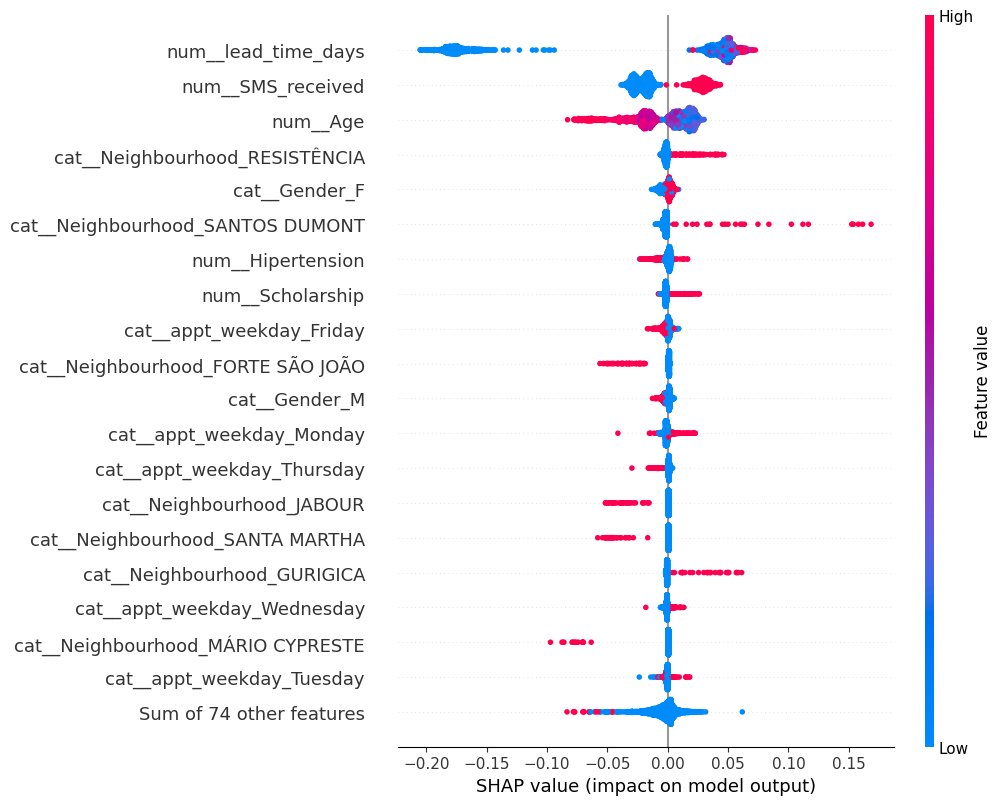

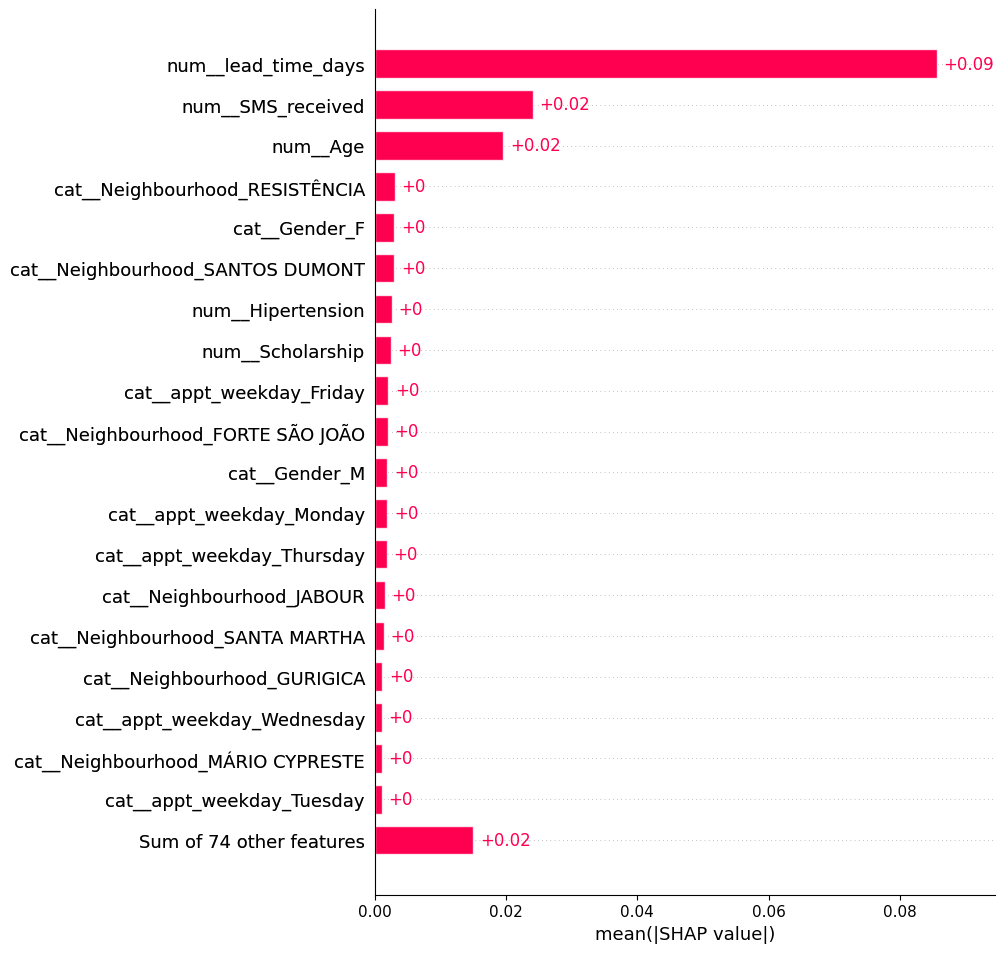

In [47]:
# Build an Explanation object explicitly
exp = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=X_shap_df.values,
    feature_names=X_shap_df.columns
)

# Beeswarm
shap.plots.beeswarm(exp, max_display=20, show=False)
plt.savefig(SHAP_DIR / "shap_summary_beeswarm_rf.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

# Bar (mean |SHAP|)
shap.plots.bar(exp, max_display=20, show=False)
plt.savefig(SHAP_DIR / "shap_bar_mean_abs_rf.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

Required Plot 2: Bar plot of mean(|SHAP|)

/tmp/ipykernel_503/4261573548.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_df, plot_type="bar", max_display=20, show=False)


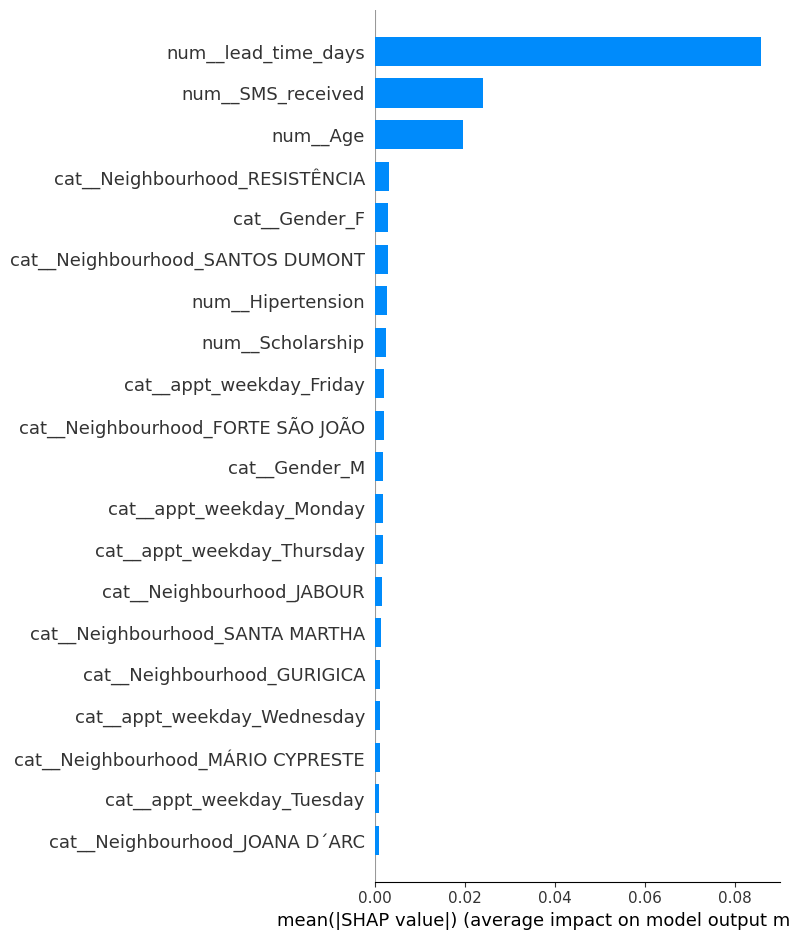

Saved: /content/artifacts/shap/shap_bar_mean_abs_rf.png


In [49]:
plt.figure()
shap.summary_plot(shap_values, X_shap_df, plot_type="bar", max_display=20, show=False)
outpath = SHAP_DIR / "shap_bar_mean_abs_rf.png"
plt.tight_layout()
plt.savefig(outpath, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", outpath)

Required Plot 3: Waterfall plot for one specific prediction

Chosen index (highest risk in test): 1378 Predicted P(no-show): 0.6941775132315453


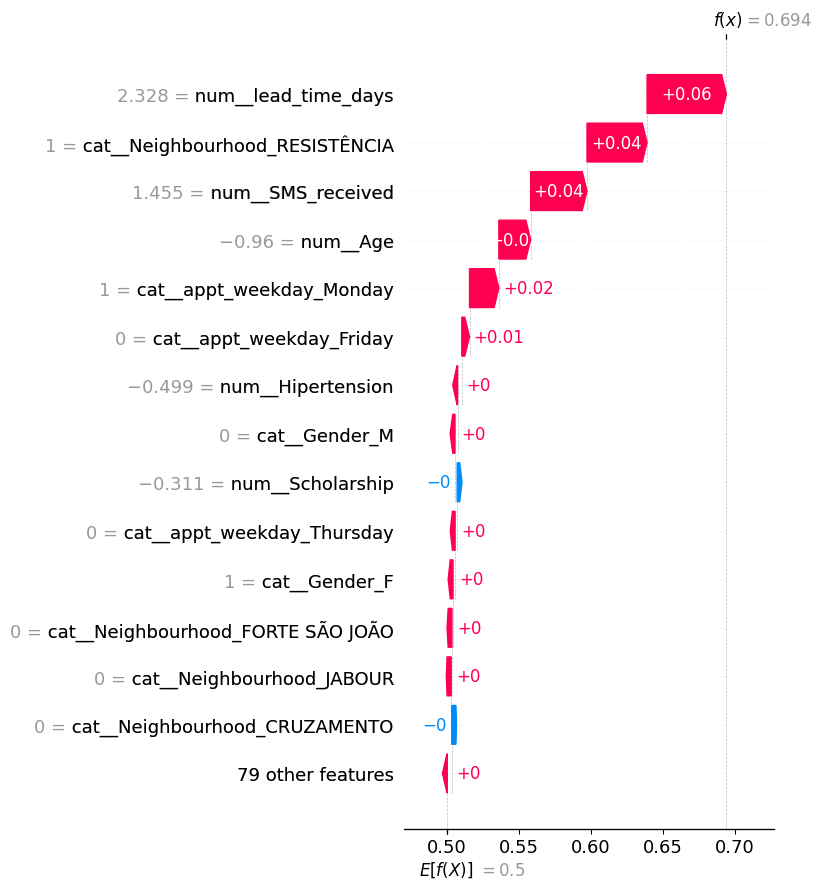

Saved: /content/artifacts/shap/shap_waterfall_high_risk_rf.png


In [42]:
# 1) Find high-risk example from test set (using the pipeline for probability)
proba_test = best_rf.predict_proba(X_test)[:, 1]
i = int(np.argmax(proba_test))
print("Chosen index (highest risk in test):", i, "Predicted P(no-show):", float(proba_test[i]))

# 2) Transform that one row and compute SHAP for it
x_one = pre.transform(X_test.iloc[[i]])
x_one_dense = (x_one.toarray() if hasattr(x_one, "toarray") else np.array(x_one)).astype(float) # Ensure output is dense float array
x_one_df = pd.DataFrame(x_one_dense, columns=feature_names)

sv_one = explainer.shap_values(x_one_dense) # Use the dense float array

# Adjust this section to correctly extract shap_one and base_one for class 1
if isinstance(sv_one, list):
    # If explainer returns a list [shap_values_class0, shap_values_class1]
    shap_one = sv_one[1] # For single instance, this is already 1D (num_features,)
    base_one = explainer.expected_value[1]
else:
    # If explainer returns a numpy array (1, num_features, num_classes)
    shap_one = sv_one[0, :, 1] # Select the first instance, all features, and class 1
    base_one = explainer.expected_value[1] # Select expected value for class 1

# 3) Build Explanation and plot waterfall
exp = shap.Explanation(values=shap_one, base_values=base_one, data=x_one_df.iloc[0], feature_names=feature_names)

plt.figure()
shap.plots.waterfall(exp, max_display=15, show=False)
outpath = SHAP_DIR / "shap_waterfall_high_risk_rf.png"
plt.tight_layout()
plt.savefig(outpath, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", outpath)

Print top drivers

In [45]:
# Mean absolute SHAP for ranking
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:10]

top_features = pd.DataFrame({
    "feature": feature_names[top_idx],
    "mean_abs_shap": mean_abs[top_idx],
    "mean_shap_signed": shap_values.mean(axis=0)[top_idx],
}).reset_index(drop=True)

top_features

,feature,mean_abs_shap,mean_shap_signed
0,num__lead_time_days,0.085669,-0.020081
1,num__SMS_received,0.024127,-0.004772
2,num__Age,0.019575,-0.004469
3,cat__Neighbourhood_RESISTÊNCIA,0.003092,0.000059
4,cat__Gender_F,0.002996,-0.000561
5,cat__Neighbourhood_SANTOS DUMONT,0.002966,-0.000971
6,num__Hipertension,0.002630,-0.000845
7,num__Scholarship,0.002476,-0.000405
8,cat__appt_weekday_Friday,0.002060,-0.000724
9,cat__Neighbourhood_FORTE SÃO JOÃO,0.002013,-0.000239


1) Which features have the strongest impact on predictions?

The SHAP importance ranking shows lead_time_days is by far the strongest driver of the model’s no-show predictions (highest mean absolute SHAP = 0.0857), followed by SMS_received (0.0241) and Age (0.0196). After these top three, the remaining features (specific Neighbourhood categories, Gender_F, Hipertension, Scholarship, and appt_weekday_Friday) have much smaller average impact.

2) How do those features influence the prediction (positively or negatively)?

The signed SHAP averages for the top drivers are negative (lead_time_days = -0.0201, SMS_received = -0.0048, Age = -0.0045), meaning these features generally push the model toward a lower predicted no-show risk on average across your SHAP sample. Some location categories show small positive effects (e.g., Neighbourhood_RESISTÊNCIA has a slightly positive signed mean), indicating those neighborhood indicators can nudge predictions upward, but their influence is minor compared to lead time, SMS, and age.

3) How could these insights be useful to a decision-maker in your domain?

For a clinic (or any appointment-based local business), the model suggests that scheduling lead time is the biggest lever: policies like sending confirmations closer to the appointment date, adding extra reminders for longer lead-time bookings, or requiring a deposit for far-in-advance appointments could reduce no-shows. Since SMS_received is among the top drivers, strengthening reminder workflows (timing, message content, ensuring phone numbers are valid) is a practical intervention. Finally, even though neighborhood and weekday signals are smaller, they can support targeted outreach (e.g., extra reminders for certain neighborhoods or Fridays) rather than applying the same reminder intensity to every appointment.